# Frozen Production Decoder Staged Geometry Refiner

Train a three-stage transformer refiner from a frozen FoldTree2 encoder and frozen production geometry decoder. This notebook mirrors the ALPS staged-training path locally at reduced capacity, then compares the CA trace from each refinement stage with the true structure.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import copy
import inspect
import os
import re
import shlex
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.loader import DataLoader

REPO = Path("/home/dmoi/projects/foldtree2/foldtree2")
os.chdir(REPO)
os.environ.setdefault("PYTHONPATH", str(REPO.parent))

print("repo:", REPO)
print("python:", sys.executable)
print("cuda:", torch.cuda.is_available())


repo: /home/dmoi/projects/foldtree2/foldtree2
python: /home/dmoi/miniforge3/envs/foldtree2/bin/python
cuda: True


## Configuration

This is a bounded local counterpart to the ALPS staged job. The encoder and production geometry decoder stay frozen; only the three-stage refiner is optimized. The local model uses 128 hidden channels, 4 heads, and 2 layers per stage, compared with ALPS at 512 channels, 8 heads, and 4 layers per stage.

dataset: /home/dmoi/projects/foldtree2/structs_train_final.h5
structures: 4999
sample index: 0
sample identifier: A0A011P981
sample node types: ['AA', 'R_true', 'bondangles', 'coords', 'fourier1di', 'fourier1dr', 'fourier2di', 'fourier2dr', 'godnode', 'godnode4decoder', 'plddt', 'positions', 'res', 'ss', 't_true']
sample residue features: (65, 857)
sample CA coordinates: (65, 3)


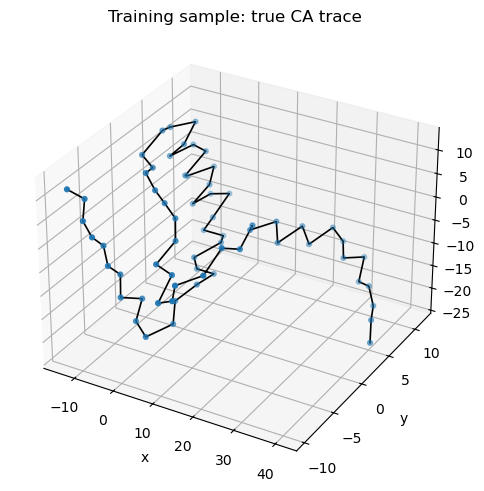

In [ ]:
from foldtree2 import learn_geometry_lightning as base
from foldtree2.src import pdbgraphmk2

DATASET = REPO.parent / "structs_train_final.h5"
if not DATASET.exists():
    DATASET = REPO / "notebooks" / "structs_train_final.h5"

if not DATASET.exists():
    raise FileNotFoundError(DATASET)

dataset = pdbgraphmk2.StructureDataset(str(DATASET))
if len(dataset) == 0:
    raise RuntimeError(f"Dataset has no entries: {DATASET}")

preview_index = 0
preview = dataset[preview_index]
preview_batch = next(iter(DataLoader([preview], batch_size=1, shuffle=False)))

print("dataset:", DATASET)
print("structures:", len(dataset))
print("sample index:", preview_index)
print("sample identifier:", getattr(preview, "identifier", "unknown"))
print("sample node types:", preview.node_types)
print("sample residue features:", tuple(preview["res"].x.shape))
print("sample CA coordinates:", tuple(preview["coords"].x.shape))

coords = preview["coords"].x.detach().cpu()
fig = plt.figure(figsize=(6, 5))
axis = fig.add_subplot(111, projection="3d")
axis.plot(coords[:, 0], coords[:, 1], coords[:, 2], color="black", linewidth=1.2)
axis.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=12, color="tab:blue")
axis.set_title("Training sample: true CA trace")
axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_zlabel("z")
plt.tight_layout()
plt.show()


## Model And Loss Setup

The encoder and production geometry decoder remain frozen. The staged refiner is trained with supervision at all three coordinate stages, with the final stage receiving the largest weight.

In [ ]:
cfg = dict(
    dataset=str(DATASET),
    pretrained_encoder_path="/home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_encoder_full_epoch_41.pt",
    pretrained_encoder_full_path="/home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_encoder_full_epoch_41.pt",
    pretrained_geometry_decoder_path="/home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_decoder_full_epoch_41.pt",
    fallback_latent_dim=20,
    fallback_input_dim=0,
    checkpoint_dir="/tmp/foldtree2_staged_geometry_refiner_notebook",
    epochs=10,
    limit_train_batches=200,
    limit_val_batches=20,
    batch_size=4,
    val_batch_size=1,
    target_effective_batch_size=12,
    num_workers=0,
    val_fraction=0.1,
    val_count=None,
    split_seed=42,
    seed=42,
    learning_rate=1e-4,
    weight_decay=0.0,
    lr_scheduler="cosine",
    lr_scheduler_interval="epoch",
    lr_scheduler_frequency=1,
    lr_scheduler_monitor="val/loss",
    lr_warmup_epochs=0,
    lr_min=1e-6,
    lr_step_size=10,
    lr_gamma=0.5,
    clip_grad=1.0,
    accelerator="auto",
    devices="2",
    strategy="auto",
    precision="32-true",
    save_top_k=-1,
    log_every_n_steps=1,
    nan_guard=True,
    sanitize_nonfinite_grads=True,
    use_uncertainty_weighting=False,
    production_coordinate_source="auto",
    production_coordinate_scale=1.0,
    transformer_width=256,
    transformer_layers=4,
    transformer_nheads=8,
    transformer_dropout=0.05,
    se3_num_atom_types=40,
    se3_contact_sketch_top_k=8,
    se3_contact_sketch_threshold=float("inf"),
    se3_contact_sketch_min_seq_sep=3,
    se3_contact_local_window=1,
    staged_hidden=256,
    staged_heads=8,
    staged_layers=4,
    staged_dropout=0.05,
    staged_max_step=4.0,
    staged_max_refine_delta=2.0,
    staged_use_mhc=True,
    staged_mhc_streams=4,
    staged_mhc_sinkhorn_iters=5,
    staged_mhc_temperature=1.0,
    staged_mhc_eps=1e-6,
    stage_loss_weights="0.25,0.5,1.0",
    stage_angle_loss=False,
    use_coarse_ca_loss=True,
    use_coarse_ca_step_loss=True,
    use_coarse_ca_bond_loss=True,
    use_coarse_ca_pairwise_loss=True,
    coarse_ca_weight=1.0,
    coarse_ca_step_weight=1.0,
    coarse_ca_bond_weight=0.1,
    coarse_ca_pairwise_weight=0.1,
    coarse_ca_pairwise_max_seq_sep=64,
    coarse_ca_pairwise_max_pairs=4096,
    use_coarse_backbone_loss=False,
    use_coarse_backbone_atom_loss=False,
    use_coarse_c_loss=False,
    use_coarse_cb_loss=False,
    use_coarse_n_loss=False,
    use_coarse_backbone_fape_loss=False,
    use_coarse_backbone_angle_loss=False,
    coarse_backbone_atom_weight=0.05,
    coarse_c_weight=0.05,
    coarse_cb_weight=0.05,
    coarse_n_weight=0.05,
    coarse_backbone_fape_weight=0.25,
    coarse_backbone_angle_weight=0.05,
    fape_pair_sample_size=1024,
)

Path(cfg["checkpoint_dir"]).mkdir(parents=True, exist_ok=True)
print("staged model:", cfg["staged_hidden"], "hidden /", cfg["staged_heads"], "heads /", cfg["staged_layers"], "layers")
print("mHC:", cfg["staged_use_mhc"], "streams=", cfg["staged_mhc_streams"])
print("loss stack: staged CA + staged sampled FAPE; auxiliary angle and coarse-backbone losses disabled")


staged model: 256 hidden / 8 heads / 2 layers
stage weights: 0.25,0.5,1.0
frozen inputs: encoder and production geometry decoder


## Train

This runs the same staged Lightning entry point used by the production workflow. Training logs appear below, and the next cells reload every epoch checkpoint for reconstruction inspection.

In [ ]:
def build_train_command(cfg):
    option_names = {
        "dataset": "dataset", "epochs": "epochs", "limit_train_batches": "limit-train-batches",
        "limit_val_batches": "limit-val-batches", "batch_size": "batch-size", "val_batch_size": "val-batch-size",
        "target_effective_batch_size": "target-effective-batch-size", "num_workers": "num-workers", "val_fraction": "val-fraction",
        "split_seed": "split-seed", "seed": "seed", "learning_rate": "learning-rate", "weight_decay": "weight-decay",
        "lr_scheduler": "lr-scheduler", "accelerator": "accelerator", "devices": "devices", "strategy": "strategy", "precision": "precision",
        "pretrained_encoder_path": "pretrained-encoder-path", "pretrained_encoder_full_path": "pretrained-encoder-full-path",
        "pretrained_geometry_decoder_path": "pretrained-geometry-decoder-path", "production_coordinate_source": "production-coordinate-source",
        "production_coordinate_scale": "production-coordinate-scale", "checkpoint_dir": "checkpoint-dir", "save_top_k": "save-top-k",
        "log_every_n_steps": "log-every-n-steps", "transformer_width": "transformer-width", "transformer_layers": "transformer-layers",
        "transformer_nheads": "transformer-nheads", "transformer_dropout": "transformer-dropout", "se3_num_atom_types": "se3-num-atom-types",
        "se3_contact_sketch_top_k": "se3-contact-sketch-top-k", "se3_contact_sketch_threshold": "se3-contact-sketch-threshold",
        "se3_contact_sketch_min_seq_sep": "se3-contact-sketch-min-seq-sep", "se3_contact_local_window": "se3-contact-local-window",
        "fape_pair_sample_size": "fape-pair-sample-size", "staged_hidden": "staged-hidden", "staged_heads": "staged-heads",
        "staged_layers": "staged-layers", "staged_dropout": "staged-dropout", "staged_max_step": "staged-max-step",
        "staged_max_refine_delta": "staged-max-refine-delta", "staged_mhc_streams": "staged-mhc-streams",
        "staged_mhc_sinkhorn_iters": "staged-mhc-sinkhorn-iters", "staged_mhc_temperature": "staged-mhc-temperature",
        "staged_mhc_eps": "staged-mhc-eps", "stage_loss_weights": "stage-loss-weights", "coarse_ca_weight": "coarse-ca-weight",
        "coarse_ca_step_weight": "coarse-ca-step-weight", "coarse_ca_bond_weight": "coarse-ca-bond-weight",
        "coarse_ca_pairwise_weight": "coarse-ca-pairwise-weight", "coarse_ca_pairwise_max_seq_sep": "coarse-ca-pairwise-max-seq-sep",
        "coarse_ca_pairwise_max_pairs": "coarse-ca-pairwise-max-pairs",
    }
    command = [sys.executable, "learn_production_staged_transformer_geometry.py"]
    for key, option in option_names.items():
        command.extend([f"--{option}", str(cfg[key])])
    boolean_options = {
        "use_coarse_ca_loss": "use-coarse-ca-loss", "use_coarse_ca_step_loss": "use-coarse-ca-step-loss",
        "use_coarse_ca_bond_loss": "use-coarse-ca-bond-loss", "use_coarse_ca_pairwise_loss": "use-coarse-ca-pairwise-loss",
        "staged_use_mhc": "staged-use-mhc", "stage_angle_loss": "stage-angle-loss",
    }
    for key, option in boolean_options.items():
        command.append(f"--{option}" if cfg[key] else f"--no-{option}")
    command.extend([
        "--no-use-coarse-backbone-loss", "--no-use-coarse-backbone-atom-loss", "--no-use-coarse-c-loss",
        "--no-use-coarse-cb-loss", "--no-use-coarse-n-loss", "--no-use-coarse-backbone-fape-loss",
        "--no-use-coarse-backbone-angle-loss", "--no-use-frame-fape-loss", "--no-use-quat-geodesic-loss",
        "--no-use-decoder-angle-loss", "--no-use-se3", "--no-use-uncertainty-weighting", "--sanitize-nonfinite-grads",
    ])
    return command

command = build_train_command(cfg)
print(shlex.join(command))
subprocess.run(command, check=True, cwd=REPO, env=os.environ.copy())


/home/dmoi/miniforge3/envs/foldtree2/bin/python learn_production_staged_transformer_geometry.py --dataset /home/dmoi/projects/foldtree2/structs_train_final.h5 --epochs 10 --limit-train-batches 200 --limit-val-batches 20 --batch-size 4 --val-batch-size 1 --target-effective-batch-size 12 --num-workers 0 --val-fraction 0.1 --split-seed 42 --seed 42 --learning-rate 0.0001 --weight-decay 0.0 --lr-scheduler cosine --accelerator auto --devices 2 --strategy auto --precision 32-true --pretrained-encoder-path /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_encoder_full_epoch_41.pt --pretrained-geometry-decoder-path /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_decoder_full_epoch_41.pt --production-coordinate-source auto --production-coordinate-scale 1.0 --checkpoint-dir /tmp/foldtree2_staged_geometry_refiner_notebook --save-top-k -1 --log-every-n-steps 1 --transformer-width 256 --trans

Seed set to 42


Loaded pretrained encoder via torch.load(module) from /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_encoder_full_epoch_41.pt epoch=None
latent_dim: 20 vq_probe: 0.09455927461385727
Loaded frozen production geometry decoder from /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_decoder_full_epoch_41.pt


/home/dmoi/miniforge3/envs/foldtree2/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX PRO 4000 Blackwell') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2


Production staged transformer training: hidden=256 layers=2 heads=8 max_step=4.0 max_refine_delta=2.0 micro_batch_size=4 accumulation=3


...

Epoch 0:   1%|          | 2/200 [00:02<03:39,  0.90it/s, v_num=49, train/loss_step=46.10]

[rank1]:[W904 11:41:17.085514653 reducer.cpp:1457] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
[rank0]:[W904 11:41:17.085599002 reducer.cpp:1457] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a 

Epoch 0: 100%|██████████| 200/200 [03:16<00:00,  1.02it/s, v_num=49, train/loss_step=38.40]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 200/200 [03:09<00:00,  1.05it/s, v_num=49, train/loss_step=35.90, val/loss=36.20, train/loss_epoch=38.30]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2:  50%|████▉     | 99/200 [01:35<01:37,  1.03it/s, v_num=49, train/loss_step=38.00, val/loss=35.10, train/loss_epoch=35.00] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


KeyboardInterrupt: 

## Checkpoint Reconstructions

The following cells reload the refiner checkpoint from each epoch and display the true CA trace beside stage 1, stage 2, and stage 3 predictions.

In [ ]:
from types import SimpleNamespace

from learn_geometry_lightning import build_encoder, ensure_edge_attrs_inplace, ensure_float32_inplace
from learn_production_geometry_se3_lightning import load_production_decoder
from learn_production_staged_transformer_geometry import ProductionStagedTransformerModule
from foldtree2.src.se3_struct_decoder import StagedTransformerRefiner

args = SimpleNamespace(**cfg)

probe = ensure_edge_attrs_inplace(ensure_float32_inplace(copy.deepcopy(preview_batch)), edge_dim=1)
device = torch.device("cuda" if torch.cuda.is_available() and args.accelerator != "cpu" else "cpu")
probe = probe.to(device)
encoder, latent_dim = build_encoder(args, probe, device)
production_decoder = load_production_decoder(args.pretrained_geometry_decoder_path, device)

with torch.no_grad():
    probe_z, _ = encoder(probe)
    probe["res"].x = probe_z
    production_output = production_decoder(probe, contact_pred_index=None)

production_z = production_output.get("z")
if production_z is None or production_z.ndim != 2:
    raise RuntimeError("Production decoder probe did not return z with shape [N,D]")

staged_refiner = StagedTransformerRefiner(
    input_dim=latent_dim * 2 + int(production_z.shape[-1]),
    num_atom_types=args.se3_num_atom_types,
    hidden=args.staged_hidden,
    heads=args.staged_heads,
    layers=args.staged_layers,
    dropout=args.staged_dropout,
    max_step=args.staged_max_step,
    max_refine_delta=args.staged_max_refine_delta,
).to(device).float()

print("device:", device)
print("encoder latent dimension:", latent_dim)
print("production decoder z dimension:", production_z.shape[-1])
print("staged refiner parameters:", sum(p.numel() for p in staged_refiner.parameters()))


Loaded pretrained encoder via torch.load(module) from /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_encoder_full_epoch_41.pt epoch=None
latent_dim: 20 vq_probe: 0.18077781796455383
Loaded frozen production geometry decoder from /home/dmoi/projects/foldtree2/models/production/40char_minimal_decoder/final_40char_mk2_contactsfix_aa_decoder_full_epoch_41.pt
device: cuda
encoder latent dimension: 20
production decoder z dimension: 30
staged refiner parameters: 4839076


In [ ]:
def staged_module_kwargs():
    aliases = {"lr_scheduler_name": "lr_scheduler", "max_epochs": "epochs", "clip_grad_norm": "clip_grad"}
    kwargs = {}
    for name in inspect.signature(base.GeometryFocusedModule.__init__).parameters:
        if name in {"self", "encoder", "transformer_geom_decoder", "se3_decoder", "se3_atom_decoder", "use_se3"}:
            continue
        source = aliases.get(name, name)
        if hasattr(args, source):
            kwargs[name] = getattr(args, source)
    kwargs.update(train_se3_only=False)
    return kwargs


def predict_stages(module, batch):
    prediction_batch = ensure_edge_attrs_inplace(ensure_float32_inplace(copy.deepcopy(batch)), edge_dim=1)
    with torch.no_grad():
        z_local, _ = module.encoder(prediction_batch)
        token_ids = module._get_ft2_token_ids(z_local)
        codebook_vectors = module._get_codebook_vectors(module.encoder, token_ids)
        prediction_batch["res"].x = z_local
        output = module._prepare_production_outputs(prediction_batch)
        _, _, _, _, _, batch_idx = base.get_true_geometry(prediction_batch)
        features = torch.cat([z_local.float(), codebook_vectors.float(), output["se3_contact_z"].float()], dim=-1)
        contacts = module._geometry_dot_contact_sketch(
            output["se3_contact_z"],
            batch_idx,
            contact_temp=getattr(module.transformer_geom_decoder, "contact_temp", None),
            contact_bias=getattr(module.transformer_geom_decoder, "contact_bias", None),
        )
        stages = module.staged_refiner(features, token_ids, output["seed_coords"], contacts, batch_idx)
    return {name: stage["coords"].detach().cpu() for name, stage in stages.items()}


def checkpoint_sort_key(path):
    match = re.search(r"epoch=(\d+)-step=(\d+)", path.stem)
    if match is None:
        return (-1, -1)
    return int(match.group(1)), int(match.group(2))


checkpoint_candidates = sorted(
    Path(cfg["checkpoint_dir"]).glob("production-staged-transformer-epoch=*.ckpt"),
    key=checkpoint_sort_key,
)
if not checkpoint_candidates:
    raise FileNotFoundError(f"No production staged checkpoints found in {cfg['checkpoint_dir']}")

# Keep the highest-step checkpoint for each epoch when several snapshots exist.
checkpoints_by_epoch = {}
for checkpoint in checkpoint_candidates:
    epoch, step = checkpoint_sort_key(checkpoint)
    if epoch not in checkpoints_by_epoch or step > checkpoint_sort_key(checkpoints_by_epoch[epoch])[1]:
        checkpoints_by_epoch[epoch] = checkpoint

epoch_previews = []
for epoch, checkpoint in sorted(checkpoints_by_epoch.items()):
    checkpoint_data = torch.load(checkpoint, map_location="cpu", weights_only=False)
    checkpoint_refiner = checkpoint_data.get("hyper_parameters", {}).get("staged_refiner")
    if checkpoint_refiner is None:
        raise RuntimeError(f"Checkpoint has no serialized staged_refiner: {checkpoint}")

    module = ProductionStagedTransformerModule.load_from_checkpoint(
        str(checkpoint),
        encoder=encoder,
        transformer_geom_decoder=production_decoder,
        staged_refiner=checkpoint_refiner,
        production_coordinate_source=args.production_coordinate_source,
        production_coordinate_scale=args.production_coordinate_scale,
        stage_loss_weights=args.stage_loss_weights,
        map_location=device,
        weights_only=False,
        **staged_module_kwargs(),
    ).eval().to(device)
    sample_prediction = predict_stages(module, preview_batch.to(device))
    epoch_previews.append({
        "epoch": epoch,
        "checkpoint": checkpoint,
        "stages": sample_prediction,
    })

print("loaded checkpoints:")
for preview_result in epoch_previews:
    refiner = preview_result["checkpoint"]
    print(f"  epoch {preview_result['epoch']}: {refiner.name}")


loaded checkpoints:
  epoch 0: production-staged-transformer-epoch=00-step=2000.ckpt


## Sample Reconstruction At Each Epoch

Each row compares the same true structure with the three staged CA predictions. Coordinates are centered independently so the comparison emphasizes trace shape.

In [ ]:
def center(coords):
    return coords - coords.mean(dim=0, keepdim=True)


def plot_trace(axis, coords, title, color):
    coords = center(coords)
    axis.plot(coords[:, 0], coords[:, 1], coords[:, 2], color=color, linewidth=1.2, alpha=0.85)
    axis.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=10, color=color, alpha=0.85)
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_zlabel("z")


if not epoch_previews:
    raise RuntimeError("Run the checkpoint reload cell first.")

true_coords = preview["coords"].x.detach().cpu()
fig = plt.figure(figsize=(16, 4 * len(epoch_previews)))
for row_index, preview_result in enumerate(epoch_previews):
    traces = [("true", true_coords, "black")]
    traces.extend((name, preview_result["stages"][name], color) for name, color in (
        ("stage1", "tab:orange"),
        ("stage2", "tab:blue"),
        ("stage3", "tab:green"),
    ))
    epoch_name = preview_result["checkpoint"].stem
    for column_index, (name, coords, color) in enumerate(traces, start=1):
        axis = fig.add_subplot(len(epoch_previews), 4, row_index * 4 + column_index, projection="3d")
        plot_trace(axis, coords, f"{epoch_name} | {name}", color)
plt.tight_layout()
plt.show()


In [ ]:
def distance_matrix(coords):
    return torch.cdist(coords.float(), coords.float()).numpy()


final_result = epoch_previews[-1]
panels = [
    (true_coords, "true"),
    (final_result["stages"]["stage1"], "stage1"),
    (final_result["stages"]["stage2"], "stage2"),
    (final_result["stages"]["stage3"], "stage3"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4))
for axis, (coords, title) in zip(axes, panels):
    distances = distance_matrix(coords)
    image = axis.imshow(distances, cmap="magma_r", vmin=0, vmax=min(30, np.nanmax(distances)))
    axis.set_title(f"{title} CA distances")
    axis.set_xlabel("residue")
    axis.set_ylabel("residue")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
